# Deep Reinforcement Learning — Doom Agent (SS2025)

Welcome to the last assignment for the **Deep Reinforcement Learning** course (SS2025). In this notebook, you'll implement and train a reinforcement learning agent to play **Doom**.

You will:
- Set up a custom VizDoom environment with shaped rewards
- Train an agent using an approach of your choice
- Track reward components across episodes
- Evaluate the best model
- Visualize performance with replays and GIFs
- Export the trained agent to ONNX to submit to the evaluation server

In [1]:
IN_COLAB = False
USE_GOOGLE_DRIVE = False

# -------- OS / Colab detection --------
import os
import sys
import shutil
import platform
import subprocess

OS_NAME = platform.system()   # "Windows", "Linux", "Darwin"

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

print("OS:", OS_NAME, "| Colab:", IN_COLAB, "| Google Drive:", USE_GOOGLE_DRIVE)

if IN_COLAB:
  # -------- Install dependencies --------
  !apt update
  !apt install -y swig python3-numpy python3-dev cmake zlib1g-dev libjpeg-dev xvfb ffmpeg xorg-dev python3-opengl libboost-all-dev libsdl2-dev
  !pip install torch==2.10 numpy==2.4.2 matplotlib vizdoom==1.3.0 portpicker==1.6.0 gymnasium==1.2.3 onnx==1.21.0 onnx2pytorch==0.5.3 onnxscript==0.7.0 einops==0.8.2
  # -------- Clone repository --------
  !git clone https://$token@github.com/gerkone/jku.wad.git
  %cd jku.wad

  if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

# -------- Device selection --------
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

OS: Linux | Colab: True | Google Drive: False
Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
55 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire 

In [2]:
from typing import Dict, Sequence

import torch
from torch.distributions.categorical import Categorical

from collections import deque, OrderedDict
from copy import deepcopy
import random
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
from matplotlib import pyplot as plt
from PIL import Image
import vizdoom as vzd
from vizdoom import ScreenFormat

from gymnasium import Env
from torch import nn
from einops import rearrange

from agents.dqn import epsilon_greedy, update_ema
from doom_arena import VizdoomMPEnv
from doom_arena.reward import VizDoomReward
from doom_arena.render import render_episode
from IPython.display import HTML
from typing import Dict, Tuple
from doom_arena.reward import VizDoomReward


DTYPE = torch.float32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cuda


## Environment configuration

ViZDoom supports multiple visual buffers that can be used as input for training agents. Each buffer provides different information about the game environment, as seen from left to right:


Screen
- The default first-person RGB view seen by the agent.

Labels
- A semantic map where each pixel is tagged with an object ID (e.g., enemy, item, wall).

Depth
- A grayscale map showing the distance from the agent to surfaces in the scene.

Automap
- A top-down schematic view of the map, useful for global navigation tasks.

![buffers gif](https://vizdoom.farama.org/_images/vizdoom-demo.gif)

In [19]:
USE_GRAYSCALE = False  # ← flip to False for RGB

PLAYER_CONFIG = {
    # NOTE: "algo_type" defaults to POLICY in evaluation script!
    "algo_type": "QVALUE",  # OPTIONAL, change to POLICY if using policy-based (eg PPO)
    "n_stack_frames": 4,
    "extra_state": ["depth"],
    "hud": "none",
    "crosshair": True,
    "screen_format": 8 if USE_GRAYSCALE else 0,
}

In [20]:
# TODO: environment training paramters
N_STACK_FRAMES = PLAYER_CONFIG["n_stack_frames"]
NUM_BOTS = 4
EPISODE_TIMEOUT = 2000 # At test time 2000
# TODO: model hyperparams
GAMMA = 0.99 # try 0.99 OG: 0.95
EPISODES = 210
BATCH_SIZE = 32
REPLAY_BUFFER_SIZE = 5_000 # tried 50000 OG: 10_000
LEARNING_RATE = 5e-5
EPSILON_START = 1.0
EPSILON_END = 0.05 # try 0.05 OG: 0.1
EPSILON_DECAY = 0.995 # try 0.995 OG: 0.99
N_EPOCHS = 10

## Reward function
In this task, you will define a reward function to guide the agent's learning. The function is called at every step and receives the current and previous game variables (e.g., number of frags, hits taken, health).

Your goal is to combine these into a meaningful reward, encouraging desirable behavior, such as:

- Rewarding frags (enemy kills)

- Rewarding accuracy (hitting enemies)

- Penalizing damage taken

- (Optional) Encouraging survival, ammo efficiency, etc.

You can return multiple reward components, which are summed during training. Consider the class below as a great starting point!

In [21]:
class YourReward(VizDoomReward):
    def __init__(self, num_players: int):
        super().__init__(num_players)

    def __call__(
        self,
        vizdoom_reward: float,
        game_var: Dict[str, float],
        game_var_old: Dict[str, float],
        player_id: int,
    ) -> Tuple[float, float, float, float, float]:
        self._step += 1
        _ = vizdoom_reward, player_id

        rwd_hit = 2.0 * (game_var["HITCOUNT"] - game_var_old["HITCOUNT"])
        rwd_hit_taken = -0.1 * (game_var["HITS_TAKEN"] - game_var_old["HITS_TAKEN"])
        rwd_frag = 100.0 * (game_var["FRAGCOUNT"] - game_var_old["FRAGCOUNT"])

        # Small survival/time reward so the agent does not receive mostly zero reward.
        rwd_alive = 0.001

        # Small penalty for doing nothing useful too long.
        # Keep this tiny so it does not dominate hits/frags.
        rwd_step_penalty = -0.0005

        return rwd_hit, rwd_hit_taken, rwd_frag, rwd_alive, rwd_step_penalty

In [22]:
reward_fn = YourReward(num_players=1)

env = VizdoomMPEnv(
    num_players=1,
    num_bots=NUM_BOTS,
    bot_skill=0,
    doom_map="ROOM",  # NOTE simple, small map; other options: TRNM, TRNMBIG
    extra_state=PLAYER_CONFIG[
        "extra_state"
    ],  # see info about states at the beginning of 'Environment configuration' above
    episode_timeout=EPISODE_TIMEOUT,
    n_stack_frames=PLAYER_CONFIG["n_stack_frames"],
    crosshair=PLAYER_CONFIG["crosshair"],
    hud=PLAYER_CONFIG["hud"],
    screen_format=PLAYER_CONFIG["screen_format"],
    reward_fn=reward_fn,
)

Host 36229
Player 36229


## Server Evaluation

Helper function to evaluate agent in the similar style as on the challenge server.

In [23]:
def flatten_stacked_obs(obs: torch.Tensor) -> torch.Tensor:
    """
    Convert stacked ViZDoom observations from (C, T, H, W) to (C*T, H, W).

    If obs is already (C, H, W), it is returned unchanged.
    If obs is batched as (B, C, T, H, W), it becomes (B, C*T, H, W).
    """
    if obs.ndim == 4:
        c, t, h, w = obs.shape
        return obs.reshape(c * t, h, w)

    if obs.ndim == 5:
        b, c, t, h, w = obs.shape
        return obs.reshape(b, c * t, h, w)

    return obs

In [24]:
# ================================================================
# Epsilon-greedy for flattened stacked observations
# ================================================================

@torch.no_grad()
def epsilon_greedy_flat(
    env,
    model,
    obs,
    epsilon,
    device,
    dtype,
):
    if random.random() < epsilon:
        return env.action_space.sample()

    # <<< CHANGED: flatten stacked observations before Conv2D model
    obs = flatten_stacked_obs(obs)
    obs = obs.to(device=device, dtype=dtype).unsqueeze(0)

    return model(obs).argmax(dim=-1).item()

In [25]:
# ================================================================
# Helper code to evaluate over 10 episodes
# ================================================================

def _first_player_obs(obs):
    if isinstance(obs, tuple) and len(obs) == 2 and isinstance(obs[1], dict):
        obs = obs[0]
    if isinstance(obs, (list, tuple)):
        obs = obs[0]
    return obs


def _scalar_reward(reward):
    if isinstance(reward, (list, tuple)):
        reward = reward[0]
    if isinstance(reward, torch.Tensor):
        reward = reward.detach().cpu().reshape(-1)[0].item()
    elif isinstance(reward, np.ndarray):
        reward = reward.reshape(-1)[0]
    return float(reward)


def _server_like_eval_env(seed: int) -> VizdoomMPEnv:
    return VizdoomMPEnv(
        num_players=1,
        num_bots=4,
        bot_skill=0,
        doom_map="ROOM",
        episode_timeout=2000,
        screen_format=PLAYER_CONFIG["screen_format"],
        n_stack_frames=PLAYER_CONFIG["n_stack_frames"],
        extra_state=PLAYER_CONFIG.get("extra_state"),
        hud=PLAYER_CONFIG["hud"],
        crosshair=PLAYER_CONFIG["crosshair"],
        seed=seed,
    )


def _select_eval_action(model: nn.Module, obs):
    # <<< CHANGED: flatten stacked observations from (C,T,H,W) to (C*T,H,W)
    obs = flatten_stacked_obs(obs)

    obs_tensor = obs.to(device=device, dtype=DTYPE).unsqueeze(0)

    with torch.no_grad():
        logits = model(obs_tensor)

        if isinstance(logits, tuple):
            logits = logits[0]

        if PLAYER_CONFIG.get("algo_type", "POLICY") == "POLICY":
            action = Categorical(logits=logits).sample()
        else:
            action = logits.argmax(dim=-1)

    return int(action.cpu().numpy()[0])


def evaluate(model: nn.Module, env: VizdoomMPEnv, n_episodes: int = 10, seed: int | None = None) -> float:
    """
    Server-like evaluation over `n_episodes` fresh ROOM episodes.
    Returns the median reward and prints the server mean plus diagnostics.
    """
    _ = env  # kept for the original notebook call signature
    model.eval()
    rewards = []
    seed_rng = np.random.default_rng(seed)

    for episode in range(n_episodes):
        episode_seed = int(seed_rng.integers(0, 10_000_000))
        eval_env = _server_like_eval_env(seed=episode_seed)
        try:
            obs = _first_player_obs(eval_env.reset())
            done = False
            total_reward = 0.0

            while not done:
                action = _select_eval_action(model, obs)
                step_result = eval_env.step(action)

                if len(step_result) == 5:
                    obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated
                else:
                    obs, reward, done, _ = step_result

                obs = _first_player_obs(obs)
                total_reward += _scalar_reward(reward)
        finally:
            eval_env.close()

        rewards.append(total_reward)
        print(f"Episode {episode + 1:02}/{n_episodes}: seed={episode_seed}, reward={total_reward:.2f}")

    mean_reward = np.mean(rewards)
    print("Average reward over {} episodes: {:.2f}".format(n_episodes, mean_reward))
    return mean_reward

## Agent

Implement **your own agent** in the code cell that follows.

* In `agents/dqn.py` and `agents/ppo.py` you’ll find very small **skeletons**—they compile but are meant only as reference or quick tests.  
  Feel free to open them, borrow ideas, extend them, or ignore them entirely.
* The notebook does **not** import those files automatically; whatever class you define in the next cell is the one that will be trained.
* You may keep the DQN interface, switch to PPO, or try something else.
* Tweak any hyper-parameters (`PLAYER_CONFIG`, ε-schedule, optimiser, etc.) and document what you tried.


In [26]:
# ================================================================
# DQN — design your network here
# ================================================================


class DQN(nn.Module):
    """
    Deep-Q Network template.

    Expected behaviour
    ------------------
    forward(frame)      # frame: (B, C, H, W)  →  Q-values: (B, num_actions)

    What to add / change
    --------------------
    • Replace the two `NotImplementedError` lines.
    • Build an encoder (Conv2d / Conv3d) + a head (MLP or duelling).
    • Feel free to use residual blocks from `agents/utils.py` or any design you like.
    """

    def __init__(self, input_dim: int, action_space: int, hidden: int = 128):
        super().__init__()
        self.algo_type = "QVALUE"  # ← change to "POLICY" if using policy-based (eg PPO)

        # -------- TODO: define your layers ------------------------
        # Example (very small) baseline — delete or improve:
        #
        # self.encoder = nn.Sequential(
        #     nn.Conv2d(input_dim, 32, 8, stride=4), nn.ReLU(),
        #     nn.Conv2d(32, 64, 4, stride=2),       nn.ReLU(),
        #     nn.Conv2d(64, 64, 3, stride=1),       nn.ReLU(),
        # )
        # self.head = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(64 * 12 * 12, hidden), nn.ReLU(),
        #     nn.Linear(hidden, action_space),
        # )
        #
        # -----------------------------------------------------------

        # Added a stronger CNN encoder for spatial visual features
        self.encoder = nn.Sequential(
            # 128x128 -> 32x32
            nn.Conv2d(input_dim, 32, kernel_size=8, stride=4, padding=2),
            nn.ReLU(inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(64, hidden, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),

            # Added global pooling to avoid hard-coded flatten dimensions.
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )

        # Added a small MLP head that maps visual features to Q-values
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, action_space),
        )

    def forward(self, frame: torch.Tensor) -> torch.Tensor:
        # -------- TODO: implement forward -------------------------
        #
        # x = self.encoder(frame)
        # x = self.head(x)
        # return x
        #
        # -----------------------------------------------------------

        # Convert input frames into visual features
        x = self.encoder(frame)

        # Predict one Q-value per discrete action
        q_values = self.head(x)

        return q_values

In [27]:
# ================================================================
# Initialise your network
# ================================================================

# main Q-network
in_channels = env.observation_space.shape[0]  # 1 if grayscale, else 3/4
model = DQN(
    input_dim=in_channels,
    action_space=env.action_space.n,
    hidden=64,  # change or ignore
).to(device, dtype=DTYPE)


## Optional behaviour cloning warm start

We provide an optional behaviour-cloning dataset that contains all observation buffers: screen, labels, depth, and automap. You may use it to pre-train your policy before starting RL. The helper below builds a dataloader from episode `.npz` files once the dataset is available locally.

Choose `BC_TRAIN_BUFFERS` to decide which of the provided buffers your policy should receive. This choice should match your current `PLAYER_CONFIG`. For example, if your RL agent uses screen, labels, depth, and automap, use `["screen", "labels", "depth", "automap"]`; if it uses only screen and depth, use `["screen", "depth"]`.

*TIP: You'll likely run out of System RAM while loading the data on Colab. Do this step locally, as training is relatively fast even on CPU*


In [28]:
# ================================================================
# Initialise your target network and training utilities
# ================================================================

# TODO ------------------------------------------------------------
# 1. Create a target network (hard-copy or EMA)
# 2. Choose an optimiser + learning-rate schedule
# 3. Instantiate a replay buffer and set the initial epsilon value
#
# Hints:
#   model_tgt  = deepcopy(model).to(device)
#   optimiser  = torch.optim.Adam(...)
#   scheduler  = torch.optim.lr_scheduler.ExponentialLR(...)
#   replay_buf = collections.deque(maxlen=...)
# ---------------------------------------------------------------


# Create a target network as a hard copy of the online Q-network.
model_tgt = deepcopy(model).to(device=device, dtype=DTYPE)
model_tgt.load_state_dict(model.state_dict())
model_tgt.eval()

# <<< NEW: freeze target network gradients.
for param in model_tgt.parameters():
    param.requires_grad_(False)

# <<< CHANGED: conservative LR for fine-tuning after BC.
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=1e-5,
)

# <<< CHANGED: slow LR decay.
#scheduler = torch.optim.lr_scheduler.ExponentialLR(
    #optimiser,
    #gamma=0.995,
#)


# Replay buffer stores transitions:
# (state, action, reward, next_state, done)
replay_buf = deque(maxlen=REPLAY_BUFFER_SIZE)


# Initial epsilon for epsilon-greedy exploration
epsilon = EPSILON_START


# Hard target update frequency in environment steps
# The target network is copied from the online network every N steps
TARGET_UPDATE_EVERY = 1_000


# Minimum number of transitions before starting gradient updates
# This avoids training on a tiny and highly correlated replay buffer
#LEARNING_STARTS = max(1_000, BATCH_SIZE * 10)
LEARNING_STARTS = 1000


# Number of gradient updates per environment step after learning starts
# Keep this small for speed and stability
GRADIENT_STEPS = 1


# Huber loss is the standard robust DQN regression loss
dqn_loss_fn = nn.SmoothL1Loss()


# Global step counter used for target updates and logging
global_step = 0


print("Target network initialized.")
print("Replay buffer size:", REPLAY_BUFFER_SIZE)
print("Learning starts after:", LEARNING_STARTS, "transitions")
print("Target update every:", TARGET_UPDATE_EVERY, "environment steps")
print("Initial epsilon:", epsilon)
print("Initial learning rate:", optimiser.param_groups[0]["lr"])


Target network initialized.
Replay buffer size: 5000
Learning starts after: 1000 transitions
Target update every: 1000 environment steps
Initial epsilon: 1.0
Initial learning rate: 5e-05


In [29]:
# ================================================================
# Action distribution diagnostic helper
# ================================================================

@torch.no_grad()
def inspect_action_distribution(model, env, n_steps: int = 1000, seed: int = 123):
    """
    Run the current model for a few steps and count selected actions.

    This helps detect policy collapse, e.g. if the model mostly turns right.
    """
    eval_env = _server_like_eval_env(seed=seed)

    try:
        obs = _first_player_obs(eval_env.reset())
        done = False

        counts = np.zeros(env.action_space.n, dtype=np.int64)
        total_reward = 0.0
        steps = 0

        model.eval()

        while not done and steps < n_steps:
            action = _select_eval_action(model, obs)
            counts[action] += 1

            step_result = eval_env.step(action)

            if len(step_result) == 5:
                obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated
            else:
                obs, reward, done, _ = step_result

            obs = _first_player_obs(obs)
            total_reward += _scalar_reward(reward)
            steps += 1

    finally:
        eval_env.close()

    print(f"Inspected {steps} steps | reward={total_reward:.2f}")

    for action_id, count in enumerate(counts):
        pct = 100.0 * count / max(1, counts.sum())
        print(f"Action {action_id}: {count:5d} ({pct:5.1f}%)")

    return counts

In [30]:
# ================================================================
# Re-initialise model after changing n_stack_frames
# ================================================================

# Close old env if needed, then recreate env with current PLAYER_CONFIG.
try:
    env.close()
except Exception:
    pass

reward_fn = YourReward(num_players=1)

env = VizdoomMPEnv(
    num_players=1,
    num_bots=NUM_BOTS,
    bot_skill=0,
    doom_map="ROOM",
    extra_state=PLAYER_CONFIG["extra_state"],
    episode_timeout=EPISODE_TIMEOUT,
    n_stack_frames=PLAYER_CONFIG["n_stack_frames"],  # must be 4
    crosshair=PLAYER_CONFIG["crosshair"],
    hud=PLAYER_CONFIG["hud"],
    screen_format=PLAYER_CONFIG["screen_format"],
    reward_fn=reward_fn,
)

# ================================================================
# Initialise network
# ================================================================

obs = env.reset()
obs0 = _first_player_obs(obs)

# <<< CHANGED: flatten env observation if it contains stacked frames
obs0 = flatten_stacked_obs(obs0)

in_channels = obs0.shape[0]
num_actions = env.action_space.n

print("Flattened observation shape:", obs0.shape)
print("Input channels:", in_channels)
print("Action space:", num_actions)

model = DQN(
    input_dim=in_channels,
    action_space=num_actions,
    hidden=64,
).to(device=device, dtype=DTYPE)

print("Model first conv expects:", model.encoder[0].in_channels)

Host 42875
Player 42875
Flattened observation shape: torch.Size([16, 128, 128])
Input channels: 16
Action space: 8
Model first conv expects: 16


In [31]:
# ================================================================
# Re-initialise target network and RL optimizer after new model
# ================================================================

model_tgt = deepcopy(model).to(device=device, dtype=DTYPE)
model_tgt.load_state_dict(model.state_dict())
model_tgt.eval()

for param in model_tgt.parameters():
    param.requires_grad_(False)

optimiser = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=1e-5,
)

scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimiser,
    gamma=1.0,
)

replay_buf = deque(maxlen=REPLAY_BUFFER_SIZE)

epsilon = EPSILON_START
dqn_loss_fn = nn.SmoothL1Loss()
global_step = 0

print("Reinitialised RL utilities for current model.")
print("Model first conv expects:", model.encoder[0].in_channels)
print("Optimizer params belong to current model:", optimiser.param_groups[0]["params"][0] is list(model.parameters())[0])

Reinitialised RL utilities for current model.
Model first conv expects: 16
Optimizer params belong to current model: True


In [32]:
# ================================================================
# Optional BC evaluation before RL training
# ================================================================
bc_eval_score = evaluate(
    model=model,
    env=env,
    n_episodes=5,
    seed=42,
)

print(f"BC-only server-like score: {bc_eval_score:.2f}")

Host 43711
Player 43711
Episode 01/5: seed=892509, reward=-1.10
Host 34217
Player 34217
Episode 02/5: seed=7739560, reward=-0.70
Host 45971
Player 45971
Episode 03/5: seed=6545715, reward=148.00
Host 37221
Player 37221
Episode 04/5: seed=4388784, reward=-0.40
Host 34393
Player 34393
Episode 05/5: seed=4330152, reward=-0.10
Average reward over 5 episodes: 29.14
BC-only server-like score: 29.14


## RL Training loop

In [33]:
# ================================================================
# Training-only reward shaping
# ================================================================

# Assumed action mapping based on observed behaviour.
# Adjust this if your environment uses a different action mapping.
ACTION_NOOP = 0
ACTION_FORWARD = 1
ACTION_ATTACK = 2
ACTION_STRAFE_LEFT = 3
ACTION_STRAFE_RIGHT = 4
ACTION_TURN_LEFT = 5
ACTION_TURN_RIGHT = 6
ACTION_JUMP = 7


def get_game_vars_from_env(env):
    """
    Safely access current and previous ViZDoom game variables.

    Returns empty dicts if unavailable, so shaping does not crash.
    """
    try:
        unwrapped = env.envs[0].unwrapped
        gv = getattr(unwrapped, "_game_vars", {})
        gv_old = getattr(unwrapped, "_game_vars_pre", {})
        return gv, gv_old
    except Exception:
        return {}, {}


def delta_var(gv, gv_old, key: str, default: float = 0.0) -> float:
    """
    Safe difference helper for game variables.
    """
    now = gv.get(key, default)
    old = gv_old.get(key, now)
    return float(now - old)


def compute_training_reward(
    raw_reward: float,
    action: int,
    env,
) -> tuple[float, dict]:
    """
    Add small training-only shaping on top of the server-like reward.

    Important:
    - raw_reward is still the main signal.
    - shaping terms are intentionally small.
    - final evaluation still uses the server-like reward.
    """
    gv, gv_old = get_game_vars_from_env(env)

    hit_delta = delta_var(gv, gv_old, "HITCOUNT")
    frag_delta = delta_var(gv, gv_old, "FRAGCOUNT")
    hits_taken_delta = delta_var(gv, gv_old, "HITS_TAKEN")

    # Base reward from the environment/reward_fn.
    reward = float(raw_reward)

    shaping = {
        "base": float(raw_reward),
        "move": 0.0,
        "turn": 0.0,
        "attack": 0.0,
        "alive": 0.0,
        "damage_extra": 0.0,
    }

    # Small survival reward to reduce completely zero-reward episodes.
    shaping["alive"] = 0.001

    # Encourage movement, but keep it tiny.
    if action in [ACTION_FORWARD, ACTION_STRAFE_LEFT, ACTION_STRAFE_RIGHT]:
        shaping["move"] = 0.01

    # Penalize pure turning slightly if it did not produce a hit or frag.
    if action in [ACTION_TURN_LEFT, ACTION_TURN_RIGHT] and hit_delta <= 0 and frag_delta <= 0:
        shaping["turn"] = -0.003

    # Penalize shooting if it did not hit anything.
    # This helps avoid "always attack" collapse.
    if action == ACTION_ATTACK and hit_delta <= 0 and frag_delta <= 0:
        shaping["attack"] = -0.01

    # Add a tiny extra penalty for taking damage.
    # The base reward already has -0.1 * HITS_TAKEN, so keep this small.
    if hits_taken_delta > 0:
        shaping["damage_extra"] = -0.02 * hits_taken_delta

    shaped_reward = reward + sum(shaping.values()) - shaping["base"]

    return shaped_reward, shaping

In [34]:
# ---------------------  TRAINING LOOP  ----------------------
# Feel free to change EVERYTHING below:
#   • choose your own reward function
#   • track different episode statistics in `ep_metrics`
#   • switch optimiser, scheduler, update rules, etc.

#reward_list, q_loss_list = [], []
#best_eval_return, best_model = float("-inf"), None

reward_list, q_loss_list, eval_list = [], [], []
best_eval_return = float("-inf")
best_model = None

# Added evaluation RNG for reproducible but changing eval seeds
eval_seed_rng = np.random.default_rng(12345)

# Added config knobs for evaluation frequency
EVAL_EVERY = 20
EVAL_EPISODES = 3
CONFIRM_EVAL_EPISODES = 10

# Make sure epsilon uses the post-BC exploration value.
epsilon = EPSILON_START

# Evaluation/logging still uses the original unscaled reward.
REWARD_SCALE = 10.0

# Use the names from the utility-initialization cell
# replay_buf, optimiser, scheduler, model_tgt, epsilon  already exist

for episode in range(EPISODES):
    #ep_metrics = {"custom_reward": 0.0}  # ← add or replace keys as you like
    ep_metrics = {
        "custom_reward": 0.0,
        "train_reward": 0.0, # scaled rward used for DQN
        "steps": 0,
        "mean_q_loss": np.nan,
    }

    obs = env.reset()[0]
    done, ep_return = False, 0.0
    model.eval()

    while not done:
        global_step += 1

        # Select action using epsilon-greedy exploration.
        act = epsilon_greedy_flat(
            env=env,
            model=model,
            obs=obs,
            epsilon=epsilon,
            device=device,
            dtype=DTYPE,
        )

        next_obs, rwd_raw, done, _ = env.step(act)
        next_obs = next_obs[0]

        # Original server-like reward, used for logging.
        server_rwd = float(rwd_raw[0])

        # Add small training-only shaping.
        custom_rwd, shaping = compute_training_reward(
            raw_reward=server_rwd,
            action=act,
            env=env,
        )

        # Scale only the reward used for DQN targets.
        train_rwd = custom_rwd / REWARD_SCALE

        ep_metrics["custom_reward"] += custom_rwd
        ep_metrics["train_reward"] += train_rwd
        ep_metrics["steps"] += 1

        # Store transition in replay buffer.
        # Changed replay_buffer -> replay_buf to match the earlier utility cell.
        # <<< CHANGED: store replay observations on CPU in float16 to save RAM
        # This is critical because each transition stores obs and next_obs.
        replay_buf.append((
            flatten_stacked_obs(obs).detach().cpu().to(torch.float16),
            int(act),
            float(train_rwd),
            flatten_stacked_obs(next_obs).detach().cpu().to(torch.float16),
            bool(done),
        ))

        obs = next_obs
        ep_return += custom_rwd

        # ───────── learning step during rollout ────────────────────
        # Start learning only once the replay buffer has enough diverse samples.
        if len(replay_buf) >= LEARNING_STARTS:
            model.train()

            step_losses = []

            for _ in range(GRADIENT_STEPS):
                batch = random.sample(replay_buf, BATCH_SIZE)
                s, a, r, s2, d = zip(*batch)

                s = torch.stack(s).to(device=device, dtype=DTYPE)
                s2 = torch.stack(s2).to(device=device, dtype=DTYPE)

                a = torch.tensor(a, device=device, dtype=torch.long)
                r = torch.tensor(r, device=device, dtype=DTYPE)
                d = torch.tensor(d, device=device, dtype=DTYPE)

                # Current Q-values for selected actions.
                q = model(s).gather(1, a.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    # <<< CHANGED: Double DQN target
                    # Online model selects the next action, target model evaluates it.
                    next_actions = model(s2).argmax(dim=1, keepdim=True)
                    q2 = model_tgt(s2).gather(1, next_actions).squeeze(1)

                    target = r + GAMMA * q2 * (1.0 - d)

                # Changed MSE to Huber loss for more stable DQN training.
                loss = dqn_loss_fn(q, target)

                # Changed optimizer -> optimiser to match earlier code.
                optimiser.zero_grad(set_to_none=True)
                loss.backward()

                # Added gradient clipping for stability.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

                optimiser.step()

                step_losses.append(loss.item())
                q_loss_list.append(loss.item())

            if step_losses:
                ep_metrics["mean_q_loss"] = float(np.mean(step_losses))

            model.eval()

            # Hard target-network update.
            if global_step % TARGET_UPDATE_EVERY == 0:
                model_tgt.load_state_dict(model.state_dict())

                # Target network should remain frozen.
                model_tgt.eval()

    reward_list.append(ep_return)

    # Step the learning-rate scheduler once per episode.
    #scheduler.step()

    # Decay epsilon once per episode.
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Print episode diagnostics.
    recent_loss = np.mean(q_loss_list[-100:]) if q_loss_list else np.nan
    print(
        f"Ep {episode + 1:03}/{EPISODES} | "
        f"return={ep_return:7.2f} | "
        f"steps={ep_metrics['steps']:4d} | "
        f"epsilon={epsilon:.3f} | "
        f"loss100={recent_loss:.4f} | "
        f"lr={optimiser.param_groups[0]['lr']:.2e}"
    )

    # ───────── server-like evaluation for best-model tracking ──────
    # Replaced undefined run_model_episode(...) with your existing evaluate(...).
    if (episode + 1) % EVAL_EVERY == 0 or episode == EPISODES - 1:
        eval_seed = int(eval_seed_rng.integers(0, 2**31 - 1))

        eval_return = evaluate(
            model=model,
            env=env,
            n_episodes=EVAL_EPISODES,
            seed=eval_seed,
        )

        eval_list.append(
            {
                "episode": episode + 1,
                "eval_return": eval_return,
                "seed": eval_seed,
            }
        )

        print(
            f"Evaluation after episode {episode + 1:03}: "
            f"mean_return={eval_return:.2f} | "
            f"best={best_eval_return:.2f}"
        )

        if eval_return > best_eval_return:
            confirm_return = evaluate(
                model=model,
                env=env,
                n_episodes=CONFIRM_EVAL_EPISODES,
                seed=eval_seed + 1,
            )

            print(
                f"Confirm evaluation: quick={eval_return:.2f}, "
                f"confirm={confirm_return:.2f}, best={best_eval_return:.2f}"
            )

            if confirm_return > best_eval_return:
                best_eval_return = confirm_return
                best_model = deepcopy(model).to("cpu", dtype=DTYPE)
                best_model.eval()
                print(f"New confirmed best model saved with eval return {best_eval_return:.2f}")

# ---------------------  SAVE / EXPORT ---------------------------------------

# <<< NEW: compare BC-only fallback with RL fine-tuned model.
if best_model is not None:
    final_model = best_model.to(device=device, dtype=DTYPE)
    print(f"Using best RL fine-tuned model with score {best_eval_return:.2f}")
else:
    final_model = model.to(device=device, dtype=DTYPE)
    print("Using final online model.")

final_model.eval()

print("Training finished.")
print(f"Best RL eval return: {best_eval_return:.2f}")
print(f"Final epsilon: {epsilon:.3f}")

Ep 001/210 | return=   2.79 | steps=2000 | epsilon=0.995 | loss100=0.0089 | lr=5.00e-05
Ep 002/210 | return=  15.96 | steps=2000 | epsilon=0.990 | loss100=0.0005 | lr=5.00e-05
Ep 003/210 | return=   5.89 | steps=2000 | epsilon=0.985 | loss100=0.0000 | lr=5.00e-05
Ep 004/210 | return=   6.85 | steps=2000 | epsilon=0.980 | loss100=0.0000 | lr=5.00e-05
Ep 005/210 | return=   6.50 | steps=2000 | epsilon=0.975 | loss100=0.0000 | lr=5.00e-05
Ep 006/210 | return=   6.78 | steps=2000 | epsilon=0.970 | loss100=0.0000 | lr=5.00e-05
Ep 007/210 | return=   4.89 | steps=2000 | epsilon=0.966 | loss100=0.0000 | lr=5.00e-05
Ep 008/210 | return=   6.19 | steps=2000 | epsilon=0.961 | loss100=0.0000 | lr=5.00e-05
Ep 009/210 | return=   6.49 | steps=2000 | epsilon=0.956 | loss100=0.0000 | lr=5.00e-05
Ep 010/210 | return=   4.85 | steps=2000 | epsilon=0.951 | loss100=0.0000 | lr=5.00e-05
Ep 011/210 | return=   7.18 | steps=2000 | epsilon=0.946 | loss100=0.0000 | lr=5.00e-05
Ep 012/210 | return=  10.08 | st

In [35]:
# ================================================================
# Evaluate your final model here (before rendering episodes with `render_episode`).
# ================================================================
eval_score = evaluate(final_model, env, n_episodes=10)

Host 45619
Player 45619
Episode 01/10: seed=5302070, reward=-0.20
Host 40729
Player 40729
Episode 02/10: seed=3206311, reward=0.00
Host 46147
Player 46147
Episode 03/10: seed=254360, reward=-0.10
Host 46631
Player 46631
Episode 04/10: seed=4331795, reward=-0.20
Host 46737
Player 46737
Episode 05/10: seed=3855510, reward=0.00
Host 37505
Player 37505
Episode 06/10: seed=749240, reward=-1.00
Host 39093
Player 39093
Episode 07/10: seed=9449494, reward=-0.60
Host 45545
Player 45545
Episode 08/10: seed=7576396, reward=-0.40
Host 38583
Player 38583
Episode 09/10: seed=8895347, reward=-2.40
Host 42329
Player 42329
Episode 10/10: seed=7448734, reward=-0.30
Average reward over 10 episodes: -0.52


In [36]:
# ================================================================
# Action distribution diagnostic
# ================================================================

@torch.no_grad()
def inspect_action_distribution(model, env, n_steps: int = 500, seed: int = 123):
    eval_env = _server_like_eval_env(seed=seed)

    try:
        obs = _first_player_obs(eval_env.reset())
        done = False
        counts = np.zeros(env.action_space.n, dtype=np.int64)
        total_reward = 0.0
        steps = 0

        model.eval()

        while not done and steps < n_steps:
            action = _select_eval_action(model, obs)
            counts[action] += 1

            obs, reward, done, _ = eval_env.step(action)
            obs = _first_player_obs(obs)

            total_reward += _scalar_reward(reward)
            steps += 1

    finally:
        eval_env.close()

    print(f"Inspected {steps} steps | reward={total_reward:.2f}")

    for action_id, count in enumerate(counts):
        pct = 100.0 * count / max(1, counts.sum())
        print(f"Action {action_id}: {count:5d} ({pct:5.1f}%)")

    return counts


action_counts = inspect_action_distribution(
    model=final_model,
    env=env,
    n_steps=500,
    seed=123,
)

Host 33677
Player 33677
Inspected 500 steps | reward=-0.20
Action 0:     0 (  0.0%)
Action 1:     7 (  1.4%)
Action 2:     0 (  0.0%)
Action 3:     0 (  0.0%)
Action 4:   493 ( 98.6%)
Action 5:     0 (  0.0%)
Action 6:     0 (  0.0%)
Action 7:     0 (  0.0%)


## Dump to ONNX

In [37]:
import onnx
import json
import shutil
from pathlib import Path


def onnx_dump(env, model, config, filename: str, drive_dir: str | None = None):
    original_device = next(model.parameters()).device

    # Flatten stacked env observation before export.
    init_state = env.reset()[0]
    init_state = flatten_stacked_obs(init_state).unsqueeze(0).to("cpu", dtype=DTYPE)

    model_cpu = deepcopy(model).to("cpu", dtype=DTYPE)
    model_cpu.eval()

    torch.onnx.export(
        model_cpu,
        args=init_state,
        f=filename,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "output": {0: "batch_size"},
        },
        dynamo=False,
        external_data=False,
    )

    onnx_model = onnx.load(filename)

    meta = onnx_model.metadata_props.add()
    meta.key = "config"
    meta.value = json.dumps(config)

    onnx.save(onnx_model, filename)
    onnx.checker.check_model(filename)

    print(f"Best network exported to {filename}")

    if drive_dir is not None:
        drive_path = Path(drive_dir)
        drive_path.mkdir(parents=True, exist_ok=True)
        dst = drive_path / Path(filename).name
        shutil.copy2(filename, dst)
        print(f"Copied ONNX model to Google Drive: {dst}")

    model.to(original_device, dtype=DTYPE)

## Evaluation and Visualization

In this final section, you can evaluate your trained agent, inspect its performance visually, and analyze reward components over time.


Enabling replays!
Disabling replays!
Rendered episode reward: -1.10


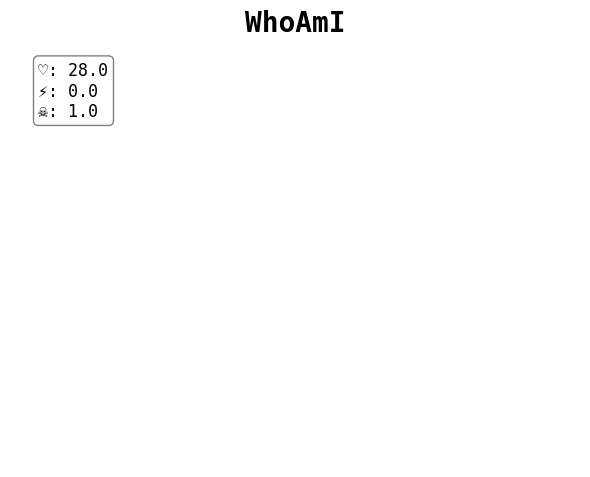

In [38]:
# ---------------------------------------------------------------
#  Reward-plot helper  (feel free to edit / extend)
# ---------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt


def plot_reward_components(reward_log, smooth_window: int = 5):
    """
    Plot raw and smoothed episode-level reward components.

    Parameters
    ----------
    reward_log : list[dict]
        Append a dict for each episode, e.g. {"frag": …, "hit": …, "hittaken": …}
    smooth_window : int
        Rolling-mean window size for the smoothed curve.
    """
    if not reward_log:
        print("reward_log is empty – nothing to plot.")
        return

    df = pd.DataFrame(reward_log)
    df_smooth = df.rolling(window=smooth_window, min_periods=1).mean()

    # raw
    plt.figure(figsize=(12, 5))
    for col in df.columns:
        plt.plot(df.index, df[col], label=col)
    plt.title("Raw episode reward components")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # smoothed
    plt.figure(figsize=(12, 5))
    for col in df.columns:
        plt.plot(df.index, df_smooth[col], label=f"{col} (avg)")
    plt.title(f"Smoothed (window={smooth_window})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------
# Hint for replay visualisation:
# ----------------------------------------------------------------
# env.enable_replay()
# ... run an evaluation episode ...
# env.disable_replay()
# replays = env.get_player_replays()
#
# from doom_arena.render import render_episode
# from IPython.display import HTML
# HTML(render_episode(replays, subsample=5).to_html5_video())
#
# Feel free to adapt or write your own GIF/MP4 export.

env.enable_replay()

obs = env.reset()[0]
done = False
total_reward = 0.0

final_model.eval()

while not done:
    action = _select_eval_action(final_model, obs)
    obs, reward, done, _ = env.step(action)
    obs = obs[0]
    total_reward += float(reward[0])

env.disable_replay()
replays = env.get_player_replays()

print(f"Rendered episode reward: {total_reward:.2f}")
HTML(render_episode(replays, subsample=5).to_html5_video())